In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.colab import drive
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from collections import Counter
from xgboost import XGBClassifier
import shap
from IPython.display import Markdown, display

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
file_path = '/content/drive/MyDrive/tese André mg feuc/datasets/stress perguntas dataset/Stress Dataset.csv'
df_raw = pd.read_csv(file_path)

print("=" * 60)
print("1.a — FACTOS RELEVANTES DO DATASET")
print("=" * 60)

# Dimensão original
print(f"\nDimensão original: {df_raw.shape[0]} registos, {df_raw.shape[1]} colunas")

# Idades fora do intervalo declarado pelos autores (18-21)
print(f"\nIdades únicas presentes: {sorted(df_raw['Age'].dropna().unique())}")
fora_intervalo = df_raw[(df_raw['Age'] < 18) | (df_raw['Age'] > 21)]
print(f"Registos com idade fora de [18, 21]: {len(fora_intervalo)} ({len(fora_intervalo)/len(df_raw)*100:.1f}%)")
print(f"Idades fora do intervalo encontradas: {sorted(fora_intervalo['Age'].unique())}")

# Distribuição de género
print(f"\nDistribuição de género (0/1): {df_raw['Gender'].value_counts().to_dict()}")

# Valores em falta
missing = df_raw.isnull().sum()
missing = missing[missing > 0]
print(f"\nColunas com valores em falta: {len(missing)}")
if len(missing) > 0:
    print(missing)

# Duplicados
print(f"\nRegistos duplicados: {df_raw.duplicated().sum()}")

# Distribuição do target
print(f"\nDistribuição do target original:")
print(df_raw['Which type of stress do you primarily experience?'].value_counts())

print("\n" + "=" * 60)
print("NOTAS METODOLÓGICAS IMPORTANTES:")
print("=" * 60)
print("1. Todos os dados são AUTODECLARADOS — incluindo as variáveis")
print("   classificadas como 'físicas'. Não há medições objectivas de sensores.")
print("2. Os autores declaram amostra de 18-21 anos, mas existem")
print(f"   {len(fora_intervalo)} registos fora desse intervalo.")
print("3. Dataset de conveniência — não representativo da população estudantil geral.")

print("\n" + "=" * 60)
print("1.b e 1.c — LIMPEZA E DATASET FINAL")
print("=" * 60)

initial_shape = df_raw.shape
df = df_raw.drop_duplicates()
df = df.dropna()
df = df.reset_index(drop=True)

print(f"Shape original:       {initial_shape}")
print(f"Após drop_duplicates: {df_raw.drop_duplicates().shape}")
print(f"Após dropna:          {df.shape}")
print(f"Registos removidos:   {initial_shape[0] - df.shape[0]}")

display(df.head())

1.a — FACTOS RELEVANTES DO DATASET

Dimensão original: 843 registos, 26 colunas

Idades únicas presentes: [np.int64(14), np.int64(15), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(24), np.int64(28), np.int64(32), np.int64(36), np.int64(37), np.int64(41), np.int64(100)]
Registos com idade fora de [18, 21]: 93 (11.0%)
Idades fora do intervalo encontradas: [np.int64(14), np.int64(15), np.int64(17), np.int64(22), np.int64(24), np.int64(28), np.int64(32), np.int64(36), np.int64(37), np.int64(41), np.int64(100)]

Distribuição de género (0/1): {0: 548, 1: 295}

Colunas com valores em falta: 0

Registos duplicados: 27

Distribuição do target original:
Which type of stress do you primarily experience?
Eustress (Positive Stress) - Stress that motivates and enhances performance.       768
No Stress - Currently experiencing minimal to no stress.                            43
Distress (Negative Stress) - Stress that causes anxiety and impairs well-bei

,Gender,Age,Have you recently experienced stress in your life?,Have you noticed a rapid heartbeat or palpitations?,Have you been dealing with anxiety or tension recently?,Do you face any sleep problems or difficulties falling asleep?,Have you been dealing with anxiety or tension recently?.1,Have you been getting headaches more often than usual?,Do you get irritated easily?,Do you have trouble concentrating on your academic tasks?,...,Are you facing any difficulties with your professors or instructors?,Is your working environment unpleasant or stressful?,Do you struggle to find time for relaxation and leisure activities?,Is your hostel or home environment causing you difficulties?,Do you lack confidence in your academic performance?,Do you lack confidence in your choice of academic subjects?,Academic and extracurricular activities conflicting for you?,Do you attend classes regularly?,Have you gained/lost weight?,Which type of stress do you primarily experience?
0,0,20,3,4,2,5,1,2,1,2,...,3,1,4,1,2,1,3,1,2,Eustress (Positive Stress) - Stress that motiv...
1,0,20,2,3,2,1,1,1,1,4,...,3,2,1,1,3,2,1,4,2,Eustress (Positive Stress) - Stress that motiv...
2,0,20,5,4,2,2,1,3,4,2,...,2,2,2,1,4,1,1,2,1,Eustress (Positive Stress) - Stress that motiv...
3,1,20,3,4,3,2,2,3,4,3,...,1,1,2,1,2,1,1,5,3,Eustress (Positive Stress) - Stress that motiv...
4,0,20,3,3,3,2,2,4,4,4,...,2,3,1,2,2,4,2,2,2,Eustress (Positive Stress) - Stress that motiv...


In [7]:
physical_features = [
    'Have you noticed a rapid heartbeat or palpitations?',
    'Have you been dealing with anxiety or tension recently?',
    'Have you been dealing with anxiety or tension recently?.1',
    'Have you been getting headaches more often than usual?',
    'Do you face any sleep problems or difficulties falling asleep?',
    'Have you been experiencing any illness or health issues?',
    'Have you gained/lost weight?'
]

subjective_features = [
    'Have you recently experienced stress in your life?',
    'Do you get irritated easily?',
    'Do you have trouble concentrating on your academic tasks?',
    'Have you been feeling sadness or low mood?',
    'Do you often feel lonely or isolated?',
    'Do you feel overwhelmed with your academic workload?',
    'Are you in competition with your peers, and does it affect you?',
    'Do you find that your relationship often causes you stress?',
    'Are you facing any difficulties with your professors or instructors?',
    'Is your working environment unpleasant or stressful?',
    'Do you struggle to find time for relaxation and leisure activities?',
    'Is your hostel or home environment causing you difficulties?',
    'Do you lack confidence in your academic performance?',
    'Do you lack confidence in your choice of academic subjects?',
    'Academic and extracurricular activities conflicting for you?',
    'Do you attend classes regularly?'
]

all_features = physical_features + subjective_features

print([f for f in all_features if f not in df.columns])

[]


In [8]:
# Distress é a classe POSITIVA (o evento que queremos detectar) → 1
# Não-Distress (Eustress + No Stress) → 0
df['y_binary'] = df['Which type of stress do you primarily experience?'].apply(
    lambda x: 1 if 'Distress' in str(x) and 'Eustress' not in str(x) else 0
)

counts = df['y_binary'].value_counts()
percentages = df['y_binary'].value_counts(normalize=True) * 100

display(pd.DataFrame({
    'Classe': ['0 — Não-Distress (Eustress + No Stress)', '1 — Distress'],
    'Count': [counts[0], counts[1]],
    'Percentage (%)': [round(percentages[0], 2), round(percentages[1], 2)]
}))

print("\nNota: Distress é a classe positiva (pos_label=1).")
print("Um classificador trivial que preveja sempre 0 teria accuracy de",
      f"{round(counts[0]/counts.sum()*100, 1)}% — por isso usamos F1 da classe positiva.")

,Classe,Count,Percentage (%)
0,0 — Não-Distress (Eustress + No Stress),787,96.45
1,1 — Distress,29,3.55



Nota: Distress é a classe positiva (pos_label=1).
Um classificador trivial que preveja sempre 0 teria accuracy de 96.4% — por isso usamos F1 da classe positiva.


In [14]:
from sklearn.preprocessing import MinMaxScaler

# 1. Scaling em todo o dataset ANTES do split (instrução do orientador)
scaler = MinMaxScaler()
X_scaled_all = pd.DataFrame(
    scaler.fit_transform(df[all_features]),
    columns=all_features
)
y = df['y_binary']

# 2. Train-test split sobre os dados já escalados
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_scaled_all, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Criar os 3 conjuntos de features
X_all_train = X_train_raw[all_features]
X_all_test  = X_test_raw[all_features]

X_physical_train = X_train_raw[physical_features]
X_physical_test  = X_test_raw[physical_features]

X_subjective_train = X_train_raw[subjective_features]
X_subjective_test  = X_test_raw[subjective_features]

# 4. Confirmar shapes e distribuição do target
print("Shapes:")
print(f"  X_all_train:        {X_all_train.shape}")
print(f"  X_all_test:         {X_all_test.shape}")
print(f"  X_physical_train:   {X_physical_train.shape}")
print(f"  X_physical_test:    {X_physical_test.shape}")
print(f"  X_subjective_train: {X_subjective_train.shape}")
print(f"  X_subjective_test:  {X_subjective_test.shape}")

print(f"\nDistress no treino: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Distress no teste:  {y_test.sum()} ({y_test.mean()*100:.1f}%)")

Shapes:
  X_all_train:        (652, 23)
  X_all_test:         (164, 23)
  X_physical_train:   (652, 7)
  X_physical_test:    (164, 7)
  X_subjective_train: (652, 16)
  X_subjective_test:  (164, 16)

Distress no treino: 23 (3.5%)
Distress no teste:  6 (3.7%)


In [24]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score
from sklearn.feature_selection import RFECV
import numpy as np

# ── RFECV com LogisticRegressionCV (Problema 6) ──────────────────────────────
print("=" * 60)
print("RFECV — LogisticRegressionCV")
print("=" * 60)

cv = StratifiedKFold(n_splits=5)

rfecv_lr = RFECV(
    estimator=LogisticRegressionCV(max_iter=1000, cv=3, scoring='f1'),
    step=1,
    cv=cv,
    scoring='f1',
    min_features_to_select=1
)
rfecv_lr.fit(X_all_train, y_train)

print(f"Features óptimas (LogisticReg): {rfecv_lr.n_features_}")

selected_lr = [f for f, s in zip(all_features, rfecv_lr.support_) if s]
print(f"\nFeatures seleccionadas ({len(selected_lr)}):")
for f in selected_lr:
    grupo = 'Physical' if f in physical_features else 'Subjective'
    print(f"  [{grupo}] {f}")

ranking_lr = pd.DataFrame({
    'Feature': all_features,
    'Ranking': rfecv_lr.ranking_,
    'Selected': rfecv_lr.support_,
    'Group': ['Physical' if f in physical_features else 'Subjective'
              for f in all_features]
}).sort_values('Ranking')

print("\nFeature Ranking Table — LogisticReg:")
display(ranking_lr)

# Comparação dos dois rankings RF vs LR
em_comum = set(selected_rf) & set(selected_lr)
so_rf    = set(selected_rf) - set(selected_lr)
so_lr    = set(selected_lr) - set(selected_rf)

print(f"\nFeatures em comum entre RF e LR ({len(em_comum)}):")
for f in em_comum:
    g = 'Physical' if f in physical_features else 'Subjective'
    print(f"  [{g}] {f}")

print(f"\nSó no RandomForest ({len(so_rf)}):")
for f in so_rf:
    g = 'Physical' if f in physical_features else 'Subjective'
    print(f"  [{g}] {f}")

print(f"\nSó na LogisticReg ({len(so_lr)}):")
for f in so_lr:
    g = 'Physical' if f in physical_features else 'Subjective'
    print(f"  [{g}] {f}")

# ── Comparação de modelos com k-fold CV (Problema 1 corrigido) ───────────────
print("\n" + "=" * 60)
print("COMPARAÇÃO DE MODELOS — 5-fold CV")
print("=" * 60)

cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# make_scorer com zero_division=0 evita o UndefinedMetricWarning
scoring = {
    'f1':        make_scorer(f1_score,        zero_division=0),
    'precision': make_scorer(precision_score, zero_division=0),
    'recall':    make_scorer(recall_score,    zero_division=0)
}

experimentos = [
    ('RandomForest', 'All',        RandomForestClassifier(n_estimators=100, random_state=42), X_all_train,        y_train),
    ('RandomForest', 'Physical',   RandomForestClassifier(n_estimators=100, random_state=42), X_physical_train,   y_train),
    ('RandomForest', 'Subjective', RandomForestClassifier(n_estimators=100, random_state=42), X_subjective_train, y_train),
    ('LogisticReg',  'All',        LogisticRegression(max_iter=1000, random_state=42),        X_all_train,        y_train),
    ('LogisticReg',  'Physical',   LogisticRegression(max_iter=1000, random_state=42),        X_physical_train,   y_train),
    ('LogisticReg',  'Subjective', LogisticRegression(max_iter=1000, random_state=42),        X_subjective_train, y_train),
]

resultados = []
for nome, grupo, modelo, X_cv, y_cv in experimentos:
    scores = cross_validate(
        modelo, X_cv, y_cv,
        cv=cv_outer,
        scoring=scoring,
        return_train_score=False
    )

    # Contar folds onde o modelo não previu nenhum Distress
    zero_folds = int((scores['test_precision'] == 0).sum())

    resultados.append({
        'Modelo':                      nome,
        'Features':                    grupo,
        'F1 (média)':                  round(scores['test_f1'].mean(), 3),
        'F1 (std)':                    round(scores['test_f1'].std(), 3),
        'Precision (média)':           round(scores['test_precision'].mean(), 3),
        'Recall (média)':              round(scores['test_recall'].mean(), 3),
        'Folds sem previsão Distress': zero_folds
    })

df_resultados = pd.DataFrame(resultados)

print("\nComparação de modelos — 5-fold CV — classe positiva: Distress (y=1)\n")
display(df_resultados.sort_values('F1 (média)', ascending=False))

print("\nNota: F1, Precision e Recall referem-se exclusivamente à classe Distress (pos_label=1).")
print("'F1 (std)' indica variabilidade entre folds — valores altos indicam instabilidade.")
print("'Folds sem previsão Distress' indica em quantos folds o modelo colapsou para a classe maioritária.")

RFECV — LogisticRegressionCV
Features óptimas (LogisticReg): 19

Features seleccionadas (19):
  [Physical] Have you noticed a rapid heartbeat or palpitations?
  [Physical] Have you been dealing with anxiety or tension recently?
  [Physical] Have you been dealing with anxiety or tension recently?.1
  [Physical] Have you been getting headaches more often than usual?
  [Physical] Do you face any sleep problems or difficulties falling asleep?
  [Physical] Have you gained/lost weight?
  [Subjective] Do you get irritated easily?
  [Subjective] Do you have trouble concentrating on your academic tasks?
  [Subjective] Have you been feeling sadness or low mood?
  [Subjective] Do you often feel lonely or isolated?
  [Subjective] Do you feel overwhelmed with your academic workload?
  [Subjective] Are you in competition with your peers, and does it affect you?
  [Subjective] Do you find that your relationship often causes you stress?
  [Subjective] Are you facing any difficulties with your professo

,Feature,Ranking,Selected,Group
0,Have you noticed a rapid heartbeat or palpitat...,1,True,Physical
1,Have you been dealing with anxiety or tension ...,1,True,Physical
2,Have you been dealing with anxiety or tension ...,1,True,Physical
3,Have you been getting headaches more often tha...,1,True,Physical
4,Do you face any sleep problems or difficulties...,1,True,Physical
6,Have you gained/lost weight?,1,True,Physical
9,Do you have trouble concentrating on your acad...,1,True,Subjective
8,Do you get irritated easily?,1,True,Subjective
12,Do you feel overwhelmed with your academic wor...,1,True,Subjective
13,"Are you in competition with your peers, and do...",1,True,Subjective



Features em comum entre RF e LR (13):
  [Subjective] Is your working environment unpleasant or stressful?
  [Physical] Have you gained/lost weight?
  [Physical] Have you been dealing with anxiety or tension recently?.1
  [Subjective] Are you in competition with your peers, and does it affect you?
  [Physical] Have you been getting headaches more often than usual?
  [Subjective] Do you struggle to find time for relaxation and leisure activities?
  [Subjective] Do you have trouble concentrating on your academic tasks?
  [Physical] Have you been dealing with anxiety or tension recently?
  [Subjective] Do you get irritated easily?
  [Subjective] Is your hostel or home environment causing you difficulties?
  [Subjective] Academic and extracurricular activities conflicting for you?
  [Subjective] Have you been feeling sadness or low mood?
  [Subjective] Do you feel overwhelmed with your academic workload?

Só no RandomForest (2):
  [Subjective] Do you lack confidence in your academic perfor

,Modelo,Features,F1 (média),F1 (std),Precision (média),Recall (média),Folds sem previsão Distress
3,LogisticReg,All,0.625,0.179,1.000,0.48,0
2,RandomForest,Subjective,0.441,0.084,0.933,0.30,0
0,RandomForest,All,0.417,0.269,0.700,0.31,1
5,LogisticReg,Subjective,0.408,0.087,1.000,0.26,0
1,RandomForest,Physical,0.394,0.230,0.800,0.27,1
4,LogisticReg,Physical,0.213,0.176,0.600,0.13,2



Nota: F1, Precision e Recall referem-se exclusivamente à classe Distress (pos_label=1).
'F1 (std)' indica variabilidade entre folds — valores altos indicam instabilidade.
'Folds sem previsão Distress' indica em quantos folds o modelo colapsou para a classe maioritária.


In [25]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score
import pandas as pd

cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'f1':        make_scorer(f1_score,        zero_division=0),
    'precision': make_scorer(precision_score, zero_division=0),
    'recall':    make_scorer(recall_score,    zero_division=0)
}

experimentos_balanced = [
    ('RandomForest', 'All',        RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'), X_all_train,        y_train),
    ('RandomForest', 'Physical',   RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'), X_physical_train,   y_train),
    ('RandomForest', 'Subjective', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'), X_subjective_train, y_train),
    ('LogisticReg',  'All',        LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),        X_all_train,        y_train),
    ('LogisticReg',  'Physical',   LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),        X_physical_train,   y_train),
    ('LogisticReg',  'Subjective', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),        X_subjective_train, y_train),
]

resultados_balanced = []
for nome, grupo, modelo, X_cv, y_cv in experimentos_balanced:
    scores = cross_validate(
        modelo, X_cv, y_cv,
        cv=cv_outer,
        scoring=scoring,
        return_train_score=False
    )
    zero_folds = int((scores['test_precision'] == 0).sum())
    resultados_balanced.append({
        'Modelo':                      nome,
        'Features':                    grupo,
        'F1 (média)':                  round(scores['test_f1'].mean(), 3),
        'F1 (std)':                    round(scores['test_f1'].std(), 3),
        'Precision (média)':           round(scores['test_precision'].mean(), 3),
        'Recall (média)':              round(scores['test_recall'].mean(), 3),
        'Folds sem previsão Distress': zero_folds
    })

df_balanced = pd.DataFrame(resultados_balanced)

print("Comparação com class_weight='balanced' — 5-fold CV\n")
display(df_balanced.sort_values('F1 (média)', ascending=False))

# Comparação directa antes vs depois
print("\n--- IMPACTO DO class_weight='balanced' ---")
df_orig = df_resultados.copy()
df_orig['Versão'] = 'Sem balanceamento'
df_bal  = df_balanced.copy()
df_bal['Versão']  = 'Com balanceamento'

comparacao = pd.concat([df_orig, df_bal]).sort_values(
    ['Modelo', 'Features', 'Versão']
)[['Modelo', 'Features', 'Versão', 'F1 (média)', 'Recall (média)', 'Folds sem previsão Distress']]

display(comparacao)

Comparação com class_weight='balanced' — 5-fold CV



,Modelo,Features,F1 (média),F1 (std),Precision (média),Recall (média),Folds sem previsão Distress
3,LogisticReg,All,0.753,0.075,0.610,1.00,0
5,LogisticReg,Subjective,0.551,0.104,0.391,0.95,0
1,RandomForest,Physical,0.380,0.221,0.733,0.27,1
0,RandomForest,All,0.341,0.188,0.800,0.22,1
2,RandomForest,Subjective,0.341,0.188,0.800,0.22,1
4,LogisticReg,Physical,0.297,0.041,0.185,0.83,0



--- IMPACTO DO class_weight='balanced' ---


,Modelo,Features,Versão,F1 (média),Recall (média),Folds sem previsão Distress
3,LogisticReg,All,Com balanceamento,0.753,1.00,0
3,LogisticReg,All,Sem balanceamento,0.625,0.48,0
4,LogisticReg,Physical,Com balanceamento,0.297,0.83,0
4,LogisticReg,Physical,Sem balanceamento,0.213,0.13,2
5,LogisticReg,Subjective,Com balanceamento,0.551,0.95,0
5,LogisticReg,Subjective,Sem balanceamento,0.408,0.26,0
0,RandomForest,All,Com balanceamento,0.341,0.22,1
0,RandomForest,All,Sem balanceamento,0.417,0.31,1
1,RandomForest,Physical,Com balanceamento,0.380,0.27,1
1,RandomForest,Physical,Sem balanceamento,0.394,0.27,1


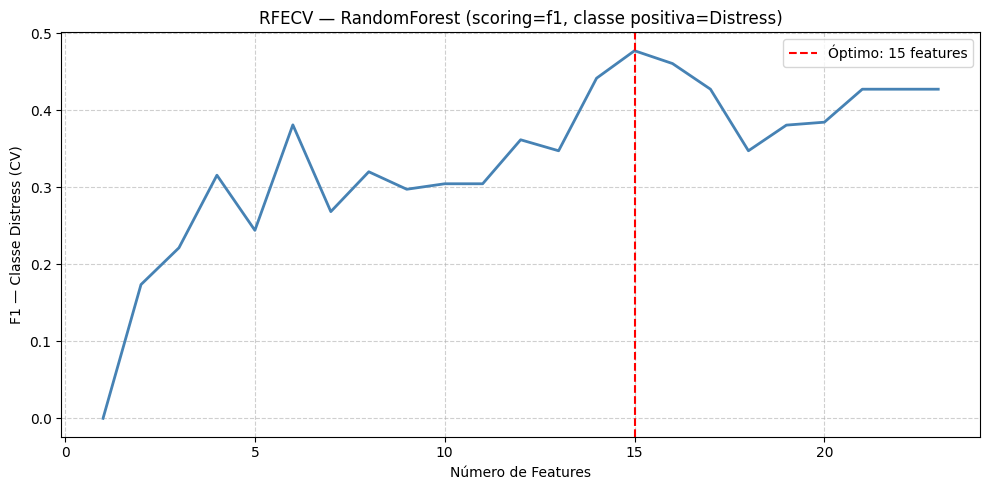

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(
    range(1, len(rfecv_rf.cv_results_['mean_test_score']) + 1),
    rfecv_rf.cv_results_['mean_test_score'],
    color='steelblue', linewidth=2
)
plt.axvline(
    rfecv_rf.n_features_, color='red', linestyle='--',
    label=f'Óptimo: {rfecv_rf.n_features_} features'
)
plt.xlabel('Número de Features')
plt.ylabel('F1 — Classe Distress (CV)')
plt.title('RFECV — RandomForest (scoring=f1, classe positiva=Distress)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [23]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import numpy as np

cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

experimentos = [
    ('RandomForest', 'All',        RandomForestClassifier(n_estimators=100, random_state=42), X_all_train,        y_train),
    ('RandomForest', 'Physical',   RandomForestClassifier(n_estimators=100, random_state=42), X_physical_train,   y_train),
    ('RandomForest', 'Subjective', RandomForestClassifier(n_estimators=100, random_state=42), X_subjective_train, y_train),
    ('LogisticReg',  'All',        LogisticRegression(max_iter=1000, random_state=42),         X_all_train,        y_train),
    ('LogisticReg',  'Physical',   LogisticRegression(max_iter=1000, random_state=42),         X_physical_train,   y_train),
    ('LogisticReg',  'Subjective', LogisticRegression(max_iter=1000, random_state=42),         X_subjective_train, y_train),
]

resultados = []
for nome, grupo, modelo, X_cv, y_cv in experimentos:
    scores = cross_validate(
        modelo, X_cv, y_cv,
        cv=cv_outer,
        scoring={
            'f1':        'f1',
            'precision': 'precision',
            'recall':    'recall'
        },
        return_train_score=False
    )
    resultados.append({
        'Modelo':        nome,
        'Features':      grupo,
        'F1 (média)':    round(scores['test_f1'].mean(), 3),
        'F1 (std)':      round(scores['test_f1'].std(), 3),
        'Precision (média)': round(scores['test_precision'].mean(), 3),
        'Recall (média)':    round(scores['test_recall'].mean(), 3),
    })

df_resultados = pd.DataFrame(resultados)

# Highlight best F1
print("Comparação de modelos — 5-fold CV — classe positiva: Distress (y=1)\n")
display(df_resultados.sort_values('F1 (média)', ascending=False))

# Nota interpretativa
print("\nNota: F1, Precision e Recall referem-se exclusivamente à classe Distress (pos_label=1).")
print("A coluna 'F1 (std)' indica a variabilidade entre folds — valores altos indicam instabilidade.")

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Comparação de modelos — 5-fold CV — classe positiva: Distress (y=1)



,Modelo,Features,F1 (média),F1 (std),Precision (média),Recall (média)
3,LogisticReg,All,0.625,0.179,1.000,0.48
2,RandomForest,Subjective,0.441,0.084,0.933,0.30
0,RandomForest,All,0.417,0.269,0.700,0.31
5,LogisticReg,Subjective,0.408,0.087,1.000,0.26
1,RandomForest,Physical,0.394,0.230,0.800,0.27
4,LogisticReg,Physical,0.213,0.176,0.600,0.13



Nota: F1, Precision e Recall referem-se exclusivamente à classe Distress (pos_label=1).
A coluna 'F1 (std)' indica a variabilidade entre folds — valores altos indicam instabilidade.


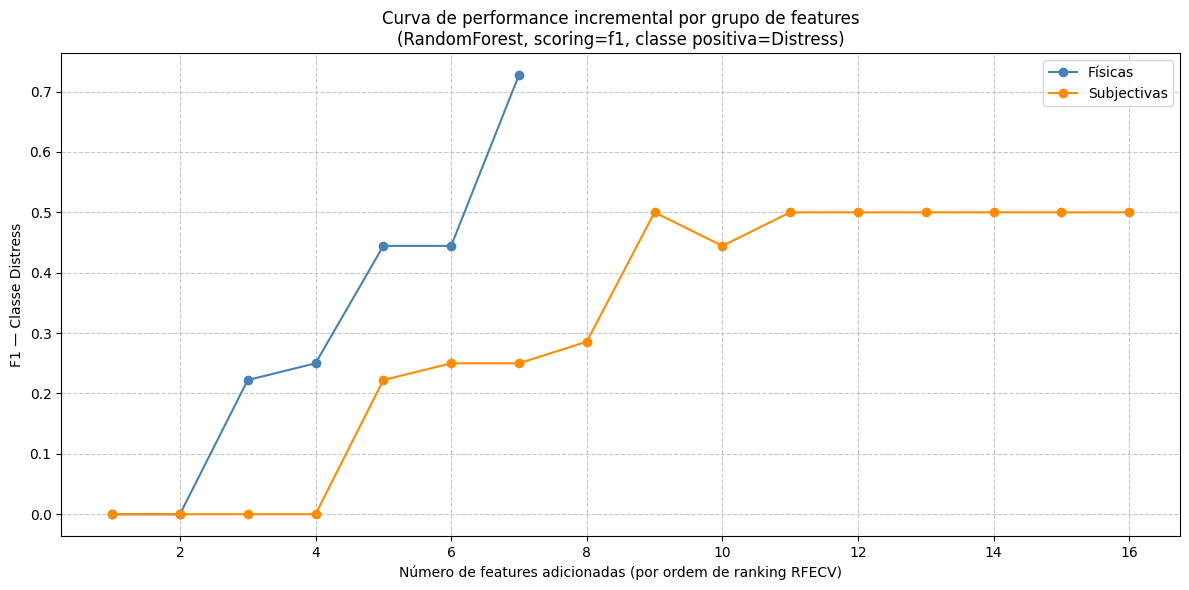


Máximo F1 Distress — Físicas:     0.727 (com 7 features)
Máximo F1 Distress — Subjectivas: 0.500 (com 9 features)


In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier

def curva_incremental(features_ordenadas, X_train, X_test, y_train, y_test, label, color):
    scores = []
    for i in range(1, len(features_ordenadas) + 1):
        feats = features_ordenadas[:i]
        m = RandomForestClassifier(n_estimators=100, random_state=42)
        m.fit(X_train[feats], y_train)
        y_pred = m.predict(X_test[feats])
        # f1 da classe positiva (Distress=1), não f1_macro
        scores.append(f1_score(y_test, y_pred, average='binary', pos_label=1))
    plt.plot(range(1, len(scores) + 1), scores, marker='o', label=label, color=color)
    return scores

physical_ordered   = ranking_rf[ranking_rf['Group'] == 'Physical'].sort_values('Ranking')['Feature'].tolist()
subjective_ordered = ranking_rf[ranking_rf['Group'] == 'Subjective'].sort_values('Ranking')['Feature'].tolist()

plt.figure(figsize=(12, 6))
s_phys = curva_incremental(physical_ordered,   X_all_train, X_all_test, y_train, y_test, 'Físicas',     'steelblue')
s_subj = curva_incremental(subjective_ordered, X_all_train, X_all_test, y_train, y_test, 'Subjectivas', 'darkorange')

plt.xlabel('Número de features adicionadas (por ordem de ranking RFECV)')
plt.ylabel('F1 — Classe Distress')
plt.title('Curva de performance incremental por grupo de features\n(RandomForest, scoring=f1, classe positiva=Distress)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"\nMáximo F1 Distress — Físicas:     {max(s_phys):.3f} (com {s_phys.index(max(s_phys))+1} features)")
print(f"Máximo F1 Distress — Subjectivas: {max(s_subj):.3f} (com {s_subj.index(max(s_subj))+1} features)")